In [1]:
import glob
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter

In [2]:
DRIVE_URL = '/content/drive/MyDrive/radar_base_general_aleman_ramirez'
LOCAL_PATH = os.getcwd()

In [3]:
def detect_environment():
    try:
        ipython_env = str(get_ipython())

        if 'google.colab' in ipython_env:
            return "Google Colab"
        elif 'zmqshell' in ipython_env:
            return "Jupyter Notebook Local"
        else:
            return "Terminal interactiva de Python"
    except NameError:
        return "Script de Python estándar (.py)"


print(f"Entorno detectado: {detect_environment()}")

Entorno detectado: Jupyter Notebook Local


In [4]:
if detect_environment() != "Google Colab":
    BASE = LOCAL_PATH
else:
    BASE = DRIVE_URL
    from google.colab import drive

    drive.mount('/content/drive')

In [5]:
RAW = os.path.join(BASE, "raw")
SCALED = os.path.join(BASE, "scaled")

os.makedirs(RAW, exist_ok=True)
os.makedirs(SCALED, exist_ok=True)

print("Carpetas listas:")
print("RAW:", RAW)
print("SCALED:", SCALED)

Carpetas listas:
RAW: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\raw
SCALED: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\scaled


In [6]:
files = sorted(glob.glob(os.path.join(RAW, "*.tif"))) + sorted(glob.glob(os.path.join(RAW, "*.tiff")))

print("Cantidad de imágenes encontradas:", len(files))
for i, a in enumerate(files, start=1):
    print(f"{i}. {os.path.basename(a)}")

Cantidad de imágenes encontradas: 10
1. 2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0.tiff
2. 2016-07-08-00_00_2016-07-08-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0.tiff
3. 2016-07-20-00_00_2016-07-20-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0.tiff
4. 2016-07-26-00_00_2016-07-26-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0.tiff
5. 2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0.tiff
6. 2016-08-13-00_00_2016-08-13-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0.tiff
7. 2016-08-19-00_00_2016-08-19-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0.tiff
8. 2016-08-25-00_00_2016-08-25-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0.tiff
9. 2016-09-06-00_00_2016-09-06-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0.tiff
10. 2016-09-12-00_00_2016-09-12-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0.tiff


In [7]:
file_test = files[0]
img = cv2.imread(file_test, cv2.IMREAD_UNCHANGED)

print("Archivo:", os.path.basename(file_test))
print("Shape:", img.shape)
print("Tipo:", img.dtype)
print("Máximo:", np.max(img))
print("Promedio:", np.mean(img))
print("Mínimo:", np.min(img))

Archivo: 2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0.tiff
Shape: (2500, 1541, 3)
Tipo: uint16
Máximo: 65535
Promedio: 29276.26192861778
Mínimo: 2868


In [8]:
if len(img.shape) == 3:
    img_gray = img[:, :, 0]
else:
    img_gray = img.copy()

print("Shape original:", img.shape)
print("Shape en una sola banda:", img_gray.shape)
print("Tipo:", img_gray.dtype)
print("Máximo:", np.max(img_gray))
print("Promedio:", np.mean(img_gray))
print("Mínimo:", np.min(img_gray))

Shape original: (2500, 1541, 3)
Shape en una sola banda: (2500, 1541)
Tipo: uint16
Máximo: 65535
Promedio: 29276.26192861778
Mínimo: 2868


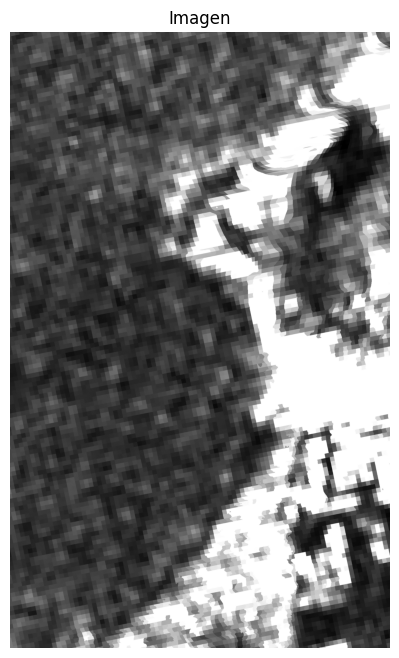

In [9]:
plt.figure(figsize=(8, 8))
plt.imshow(img_gray, cmap="gray")
plt.title("Imagen")
plt.axis("off")
plt.show()

In [10]:
def rescalar_imagen_sar(img_gray):
    """
    Reescala una imagen SAR siguiendo la lógica del repositorio:
    - convierte a float
    - calcula mean * 3 como escala de visualización
    - limita valores altos
    - normaliza a 0-255
    - devuelve uint8
    """
    img2 = img_gray.astype(np.float32)

    escala_display = np.mean(img2) * 3.0
    minimo = np.min(img2)

    img2[img2 > escala_display] = escala_display
    img2[img2 < minimo] = 0

    img3 = 255.0 * (img2 / escala_display)
    img4 = img3.astype(np.uint8)

    return img4, escala_display

In [11]:
img_scaled, escala_display = rescalar_imagen_sar(img_gray)

print("Escala de visualización:", escala_display)
print("Shape reescalada:", img_scaled.shape)
print("Tipo reescalada:", img_scaled.dtype)
print("Máximo reescalada:", np.max(img_scaled))
print("Promedio reescalada:", np.mean(img_scaled))
print("Mínimo reescalada:", np.min(img_scaled))

Escala de visualización: 87828.78
Shape reescalada: (2500, 1541)
Tipo reescalada: uint8
Máximo reescalada: 190
Promedio reescalada: 84.53318650227125
Mínimo reescalada: 8


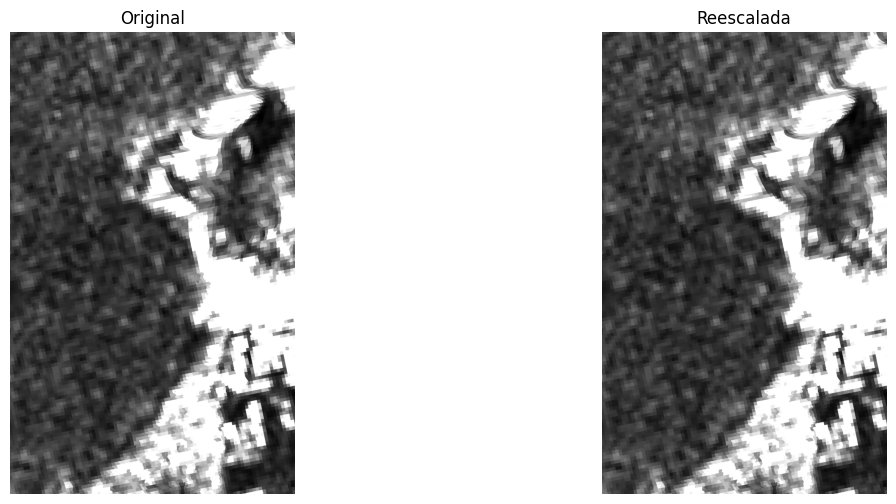

In [12]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_scaled, cmap="gray")
plt.title("Reescalada")
plt.axis("off")

plt.show()

In [13]:
nombre = os.path.basename(file_test)
base_nombre = os.path.splitext(nombre)[0]
ruta_salida = os.path.join(SCALED, base_nombre + "_scaled.tiff")

cv2.imwrite(ruta_salida, img_scaled)
print("Imagen guardada en:", ruta_salida)

Imagen guardada en: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\scaled\2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff


In [14]:
def cargar_una_banda(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"No se pudo leer: {path}")

    if len(img.shape) == 3:
        img = img[:, :, 0]

    return img


for path in files:
    img_gray = cargar_una_banda(path)
    img_scaled, _ = rescalar_imagen_sar(img_gray)

    nombre = os.path.basename(path)
    base_nombre = os.path.splitext(nombre)[0]
    salida = os.path.join(SCALED, base_nombre + "_scaled.tiff")

    cv2.imwrite(salida, img_scaled)
    print("Guardada:", salida)

Guardada: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\scaled\2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
Guardada: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\scaled\2016-07-08-00_00_2016-07-08-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
Guardada: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\scaled\2016-07-20-00_00_2016-07-20-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
Guardada: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\scaled\2016-07-26-00_00_2016-07-26-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
Guardada: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\scaled\2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
Guardada: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\scaled\2016-08-13-00_00_2016-08-13-23_59_Sentinel-1_EW_VV_VV_-_linear

In [15]:
scaled_files = sorted(glob.glob(os.path.join(SCALED, "*_scaled.tiff")))

print("Cantidad de imágenes reescaladas:", len(scaled_files))
for a in scaled_files:
    print(os.path.basename(a))

Cantidad de imágenes reescaladas: 10
2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
2016-07-08-00_00_2016-07-08-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
2016-07-20-00_00_2016-07-20-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
2016-07-26-00_00_2016-07-26-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
2016-08-13-00_00_2016-08-13-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
2016-08-19-00_00_2016-08-19-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
2016-08-25-00_00_2016-08-25-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
2016-09-06-00_00_2016-09-06-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
2016-09-12-00_00_2016-09-12-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff


In [16]:
FILTERED = os.path.join(BASE, "filtered")
os.makedirs(FILTERED, exist_ok=True)

print("Carpeta de filtradas:", FILTERED)

Carpeta de filtradas: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\filtered


In [17]:
def lee_filter(img, size=7):
    """
    Filtro Lee para reducir speckle en imágenes SAR.
    img: imagen 2D en escala de grises
    size: tamaño de ventana local
    """
    img = img.astype(np.float32)

    media_local = uniform_filter(img, size=size)
    media_cuadrado_local = uniform_filter(img ** 2, size=size)
    varianza_local = media_cuadrado_local - media_local ** 2

    varianza_global = np.var(img)

    peso = varianza_local / (varianza_local + varianza_global + 1e-8)
    img_filtrada = media_local + peso * (img - media_local)

    img_filtrada = np.clip(img_filtrada, 0, 255).astype(np.uint8)
    return img_filtrada

In [18]:
scaled_files = sorted(glob.glob(os.path.join(SCALED, "*_scaled.tiff")))

archivo_prueba = scaled_files[0]
img_scaled = cv2.imread(archivo_prueba, cv2.IMREAD_UNCHANGED)

if len(img_scaled.shape) == 3:
    img_scaled = img_scaled[:, :, 0]

print("Archivo de prueba:", os.path.basename(archivo_prueba))
print("Shape:", img_scaled.shape)
print("Tipo:", img_scaled.dtype)
print("Max:", np.max(img_scaled))
print("Mean:", np.mean(img_scaled))
print("Min:", np.min(img_scaled))

Archivo de prueba: 2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
Shape: (2500, 1541)
Tipo: uint8
Max: 190
Mean: 84.53318650227125
Min: 8


In [19]:
img_lee = lee_filter(img_scaled, size=7)

print("Imagen filtrada")
print("Shape:", img_lee.shape)
print("Tipo:", img_lee.dtype)
print("Max:", np.max(img_lee))
print("Mean:", np.mean(img_lee))
print("Min:", np.min(img_lee))

Imagen filtrada
Shape: (2500, 1541)
Tipo: uint8
Max: 190
Mean: 84.2557438027255
Min: 8


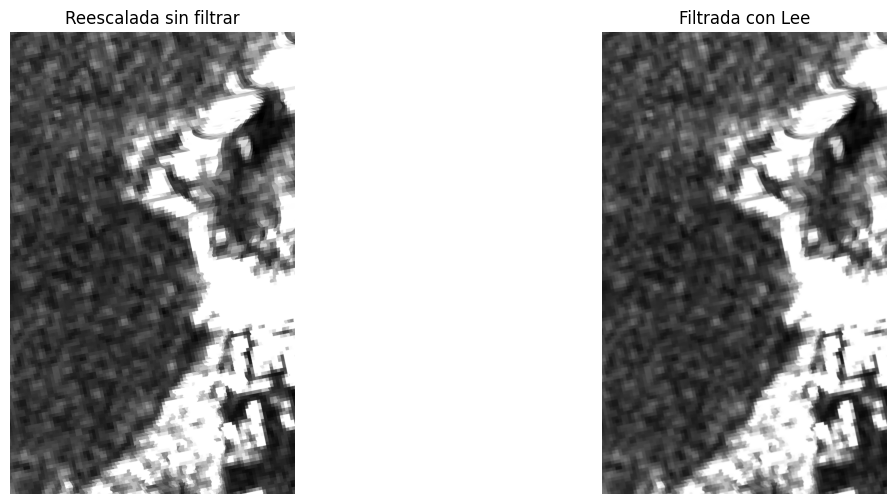

In [20]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_scaled, cmap="gray")
plt.title("Reescalada sin filtrar")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_lee, cmap="gray")
plt.title("Filtrada con Lee")
plt.axis("off")

plt.show()

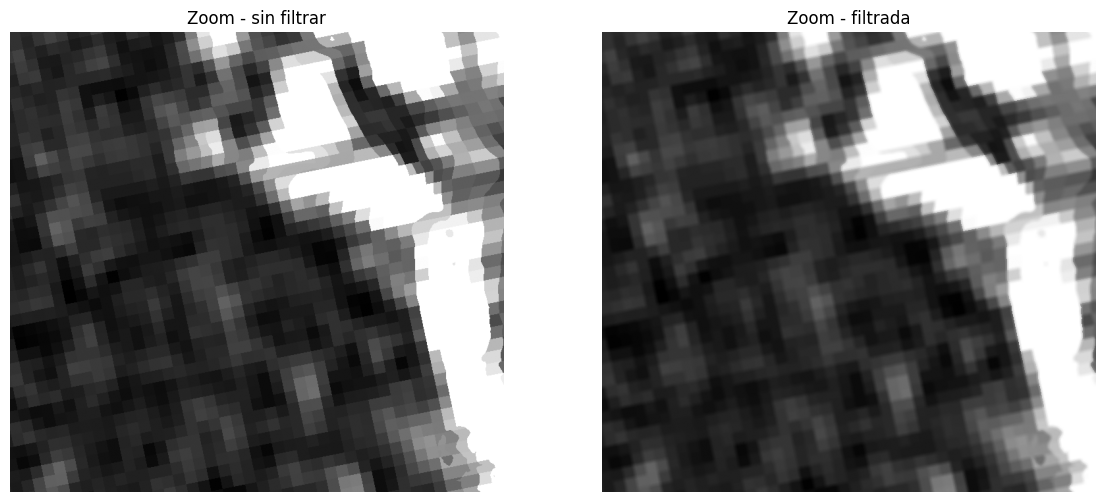

In [21]:
y1, y2 = 700, 1400
x1, x2 = 350, 1100

roi_original = img_scaled[y1:y2, x1:x2]
roi_filtrada = img_lee[y1:y2, x1:x2]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(roi_original, cmap="gray")
plt.title("Zoom - sin filtrar")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(roi_filtrada, cmap="gray")
plt.title("Zoom - filtrada")
plt.axis("off")

plt.show()

In [22]:
print("Desviación estándar antes:", np.std(img_scaled))
print("Desviación estándar después:", np.std(img_lee))

Desviación estándar antes: 56.08580178958771
Desviación estándar después: 55.68715914243838


In [23]:
nombre = os.path.basename(archivo_prueba)
base_nombre = os.path.splitext(nombre)[0]
ruta_salida = os.path.join(FILTERED, base_nombre + "_lee.tiff")

cv2.imwrite(ruta_salida, img_lee)
print("Imagen filtrada guardada en:", ruta_salida)

Imagen filtrada guardada en: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\filtered\2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff


In [24]:
for path in scaled_files:
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if len(img.shape) == 3:
        img = img[:, :, 0]

    img_filtrada = lee_filter(img, size=7)

    nombre = os.path.basename(path)
    base_nombre = os.path.splitext(nombre)[0]
    salida = os.path.join(FILTERED, base_nombre + "_lee.tiff")

    cv2.imwrite(salida, img_filtrada)
    print("Guardada:", salida)

Guardada: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\filtered\2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff
Guardada: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\filtered\2016-07-08-00_00_2016-07-08-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff
Guardada: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\filtered\2016-07-20-00_00_2016-07-20-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff
Guardada: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\filtered\2016-07-26-00_00_2016-07-26-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff
Guardada: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\filtered\2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff
Guardada: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\filtered\2016-08-13-00_00_2016-08-13-23

In [25]:
filtered_files = sorted(glob.glob(os.path.join(FILTERED, "*_lee.tiff")))

print("Cantidad de imágenes filtradas:", len(filtered_files))
for a in filtered_files:
    print(os.path.basename(a))

Cantidad de imágenes filtradas: 10
2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff
2016-07-08-00_00_2016-07-08-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff
2016-07-20-00_00_2016-07-20-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff
2016-07-26-00_00_2016-07-26-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff
2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff
2016-08-13-00_00_2016-08-13-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff
2016-08-19-00_00_2016-08-19-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff
2016-08-25-00_00_2016-08-25-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff
2016-09-06-00_00_2016-09-06-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff
2016-09-12-00_00_2016-09-12-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_lee.tiff


In [26]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

nombre_base = "2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0"

ruta_unfiltered = os.path.join(SCALED, nombre_base + "_scaled.tiff")
ruta_filtered = os.path.join(FILTERED, nombre_base + "_scaled_lee.tiff")

img_unfiltered = cv2.imread(ruta_unfiltered, cv2.IMREAD_UNCHANGED)
img_filtered = cv2.imread(ruta_filtered, cv2.IMREAD_UNCHANGED)

if len(img_unfiltered.shape) == 3:
    img_unfiltered = img_unfiltered[:, :, 0]

if len(img_filtered.shape) == 3:
    img_filtered = img_filtered[:, :, 0]

print("Sin filtrar:", img_unfiltered.shape, img_unfiltered.dtype)
print("Filtrada:", img_filtered.shape, img_filtered.dtype)

Sin filtrar: (2500, 1541) uint8
Filtrada: (2500, 1541) uint8


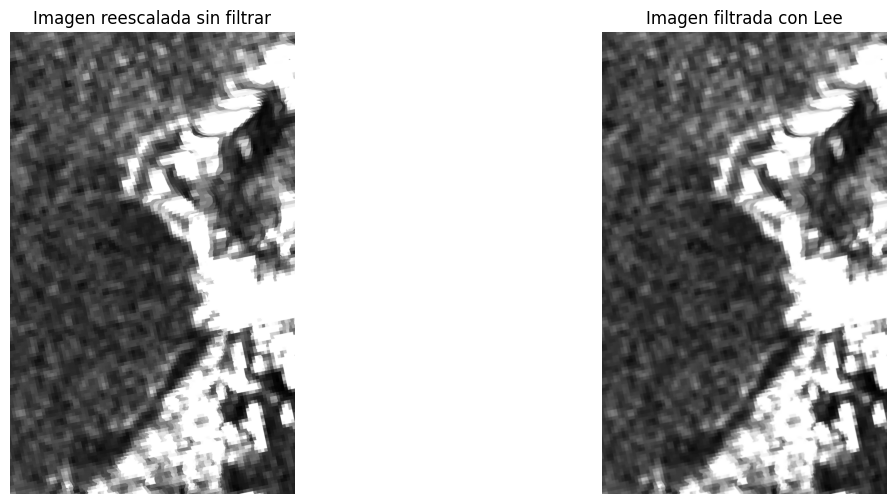

In [27]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_unfiltered, cmap="gray")
plt.title("Imagen reescalada sin filtrar")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_filtered, cmap="gray")
plt.title("Imagen filtrada con Lee")
plt.axis("off")

plt.show()

In [28]:
rois = {
    "ROI_1": (300, 900, 500, 1100),  # prueba zona superior-media
    "ROI_2": (700, 1400, 350, 1000),  # prueba zona central
    "ROI_3": (1300, 2200, 300, 1000)  # prueba zona inferior
}

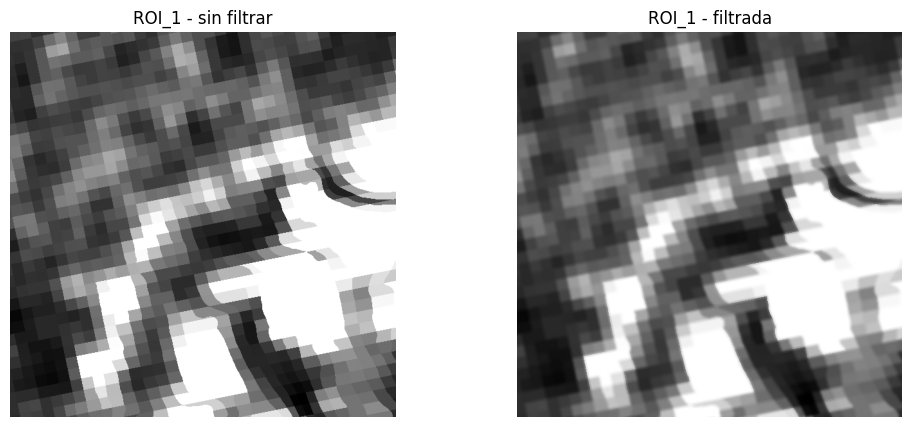

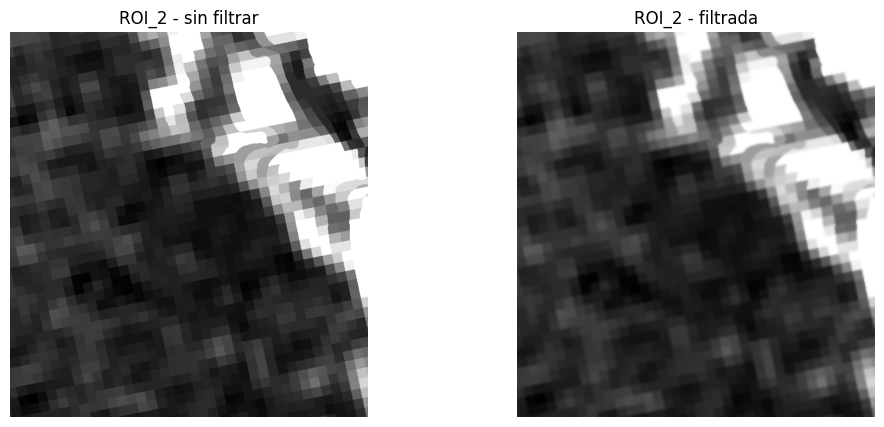

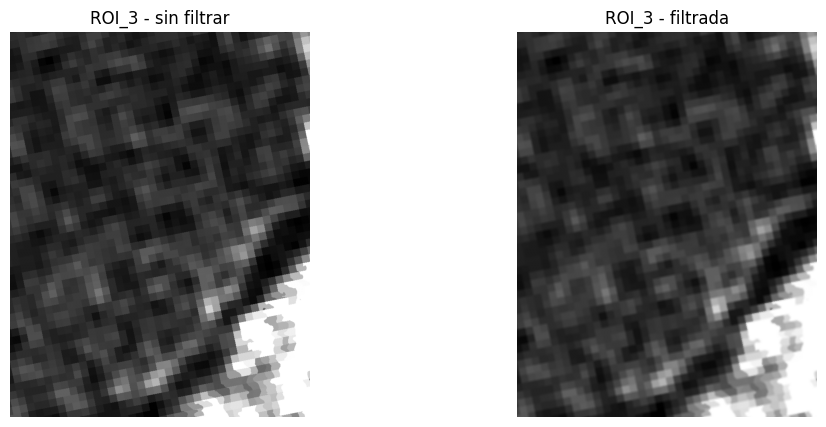

In [29]:
for nombre, (y1, y2, x1, x2) in rois.items():
    roi_unf = img_unfiltered[y1:y2, x1:x2]
    roi_flt = img_filtered[y1:y2, x1:x2]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(roi_unf, cmap="gray")
    plt.title(f"{nombre} - sin filtrar")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(roi_flt, cmap="gray")
    plt.title(f"{nombre} - filtrada")
    plt.axis("off")

    plt.show()

In [30]:
for nombre, (y1, y2, x1, x2) in rois.items():
    roi_unf = img_unfiltered[y1:y2, x1:x2]
    roi_flt = img_filtered[y1:y2, x1:x2]

    print(f"\n{nombre}")
    print("  Sin filtrar -> media:", np.mean(roi_unf), "std:", np.std(roi_unf))
    print("  Filtrada    -> media:", np.mean(roi_flt), "std:", np.std(roi_flt))


ROI_1
  Sin filtrar -> media: 104.42813333333334 std: 51.477137014234025
  Filtrada    -> media: 104.15106388888888 std: 50.74014687307747

ROI_2
  Sin filtrar -> media: 69.13526593406593 std: 50.75455614091357
  Filtrada    -> media: 68.84643296703297 std: 50.29526901506994

ROI_3
  Sin filtrar -> media: 60.13817936507937 std: 38.782598005424646
  Filtrada    -> media: 59.83462063492063 std: 38.43362838629014


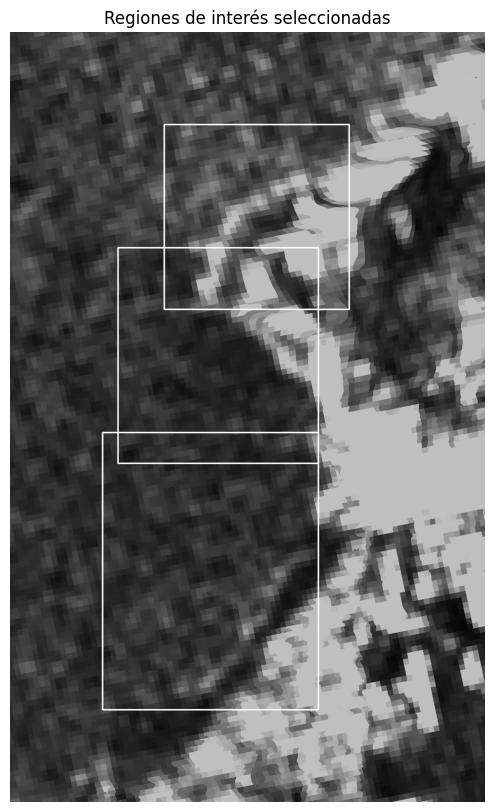

In [31]:
img_marked = cv2.cvtColor(img_unfiltered, cv2.COLOR_GRAY2BGR)

for nombre, (y1, y2, x1, x2) in rois.items():
    cv2.rectangle(img_marked, (x1, y1), (x2, y2), (255, 255, 255), 3)

plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(img_marked, cv2.COLOR_BGR2RGB))
plt.title("Regiones de interés seleccionadas")
plt.axis("off")
plt.show()

In [32]:
ANALYSIS = os.path.join(BASE, "analysis")
os.makedirs(ANALYSIS, exist_ok=True)

cv2.imwrite(os.path.join(ANALYSIS, "imagen_base_sin_filtrar.tiff"), img_unfiltered)
cv2.imwrite(os.path.join(ANALYSIS, "imagen_base_filtrada.tiff"), img_filtered)
cv2.imwrite(os.path.join(ANALYSIS, "imagen_base_rois_marcadas.png"), img_marked)

print("Evidencias guardadas en:", ANALYSIS)

Evidencias guardadas en: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\analysis
